# 📊 Tarea paso a paso: Gráficos de Regresión

**¡ATENCIÓN! Lee esto antes de empezar:**
Esta tarea está diseñada paso a paso para que afiances los conceptos vistos en clase sobre el modelado visual mediante líneas de regresión. Su objetivo es que practiques cómo visualizar y evaluar matemáticamente (de forma visual) la tendencia que existe entre dos variables numéricas.

⚠️ **Nota importante sobre la Inteligencia Artificial:**
Es tentador copiar y pegar el enunciado de estos ejercicios en ChatGPT o Claude para que te den la solución... **Hacer eso perjudicará gravemente tu aprendizaje. (CODEA UN POCO QUE TE ENTERES QUE HACES)**. La única forma de asimilar la sintaxis de las herramientas de visualización es escribiéndolas. **Usa tu cerebro, actúa paso a paso, equivócate, lee la documentación de Python (Matplotlib y Seaborn), busca tu fallo y ¡aprende de él!**

## 📁 Preparación y Datos

Para esta tarea vamos a utilizar un dataset nuevo de Kaggle: el **"World Happiness Report"** (Informe Mundial de la Felicidad).
Este dataset nos permitirá descubrir qué factores (como la riqueza del país o la esperanza de vida) afectan al índice de felicidad global.

1. Descarga el dataset de Kaggle: [World Happiness Report](https://www.kaggle.com/datasets/unsdsn/world-happiness) (puedes descargar el año 2019.csv o 2015.csv, el que prefieras, asumiendo columnas de `GDP per capita` y `Score`).
2. Guarda el archivo en la carpeta `data/` de tu proyecto.
3. En la siguiente celda, importa las librerías necesarias (`pandas`, `matplotlib.pyplot`, `seaborn`) y carga el CSV en un DataFrame llamado `df`. Imprime las primeras filas.

In [7]:
# Importamos las librerías que vamos a usar
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configuramos un estilo sencillo para las gráficas
sns.set_style("whitegrid")

# Cargamos el dataset de happiness
df = pd.read_csv("data/2015.csv")

# Mostramos las primeras filas para revisar los datos
df.head()


,Country,Region,Happiness Rank,Happiness Score,Standard Error,Economy (GDP per Capita),Family,Health (Life Expectancy),Freedom,Trust (Government Corruption),Generosity,Dystopia Residual
0,Switzerland,Western Europe,1,7.587,0.03411,1.39651,1.34951,0.94143,0.66557,0.41978,0.29678,2.51738
1,Iceland,Western Europe,2,7.561,0.04884,1.30232,1.40223,0.94784,0.62877,0.14145,0.43630,2.70201
2,Denmark,Western Europe,3,7.527,0.03328,1.32548,1.36058,0.87464,0.64938,0.48357,0.34139,2.49204
3,Norway,Western Europe,4,7.522,0.03880,1.45900,1.33095,0.88521,0.66973,0.36503,0.34699,2.46531
4,Canada,North America,5,7.427,0.03553,1.32629,1.32261,0.90563,0.63297,0.32957,0.45811,2.45176


## 🛠️ Paso 1: Gráfico de Regresión Básico

**Objetivo:** Analizar la tendencia general y la fuerza de la relación entre el poder económico y la felicidad.

**Instrucciones:**
1. Crea un gráfico de regresión utilizando la librería Seaborn (pista: usa la función `regplot` o `lmplot`).
2. Configura el eje X con la columna que representa el PIB per cápita (ej: `Economy (GDP per Capita)` o `GDP per capita`).
3. Configura el eje Y con la puntuación de felicidad (ej: `Happiness Score` o `Score`).
4. Observa si la línea de regresión muestra una tendencia positiva (hacia arriba) o negativa.

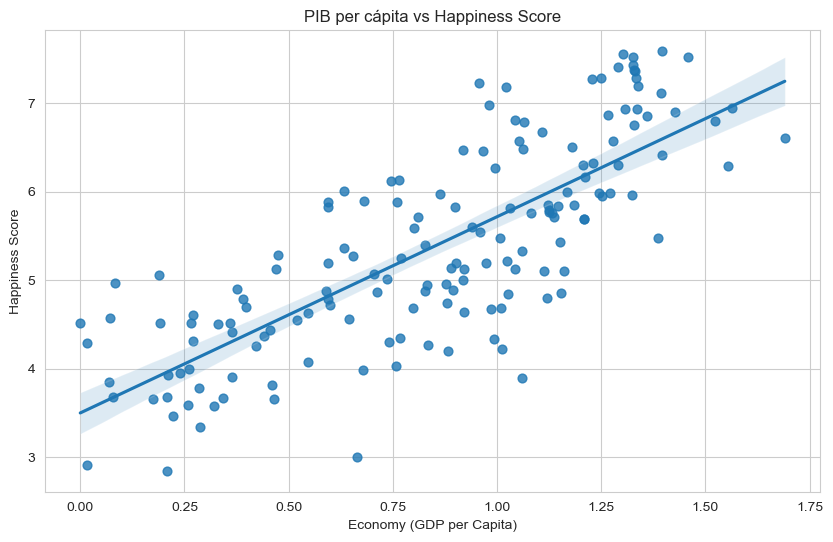

In [8]:
# Creamos una figura para el gráfico
plt.figure(figsize=(10, 6))

# Dibujamos la regresión entre PIB per cápita y felicidad
sns.regplot(
    data=df,
    x='Economy (GDP per Capita)',
    y='Happiness Score',
    scatter_kws={'s': 40}
)

# Añadimos un título y etiquetas a los ejes
plt.title('PIB per cápita vs Happiness Score')
plt.xlabel('Economy (GDP per Capita)')
plt.ylabel('Happiness Score')
plt.show()


## 🛠️ Paso 2: Análisis con otra variable

**Objetivo:** Repetir el análisis visual con un factor diferente para comparar qué variable se agrupa mejor a la línea de regresión.

**Instrucciones:**
1. Haz un nuevo gráfico de regresión igual al paso anterior.
2. Esta vez cambia el eje X para utilizar la esperanza de vida (ej: `Health (Life Expectancy)` o `Healthy life expectancy`). El eje Y sigue siendo `Score`.
3. Compara visualmente: ¿Están los puntos más cerca o más lejos de la línea en comparación con el gráfico del PIB?

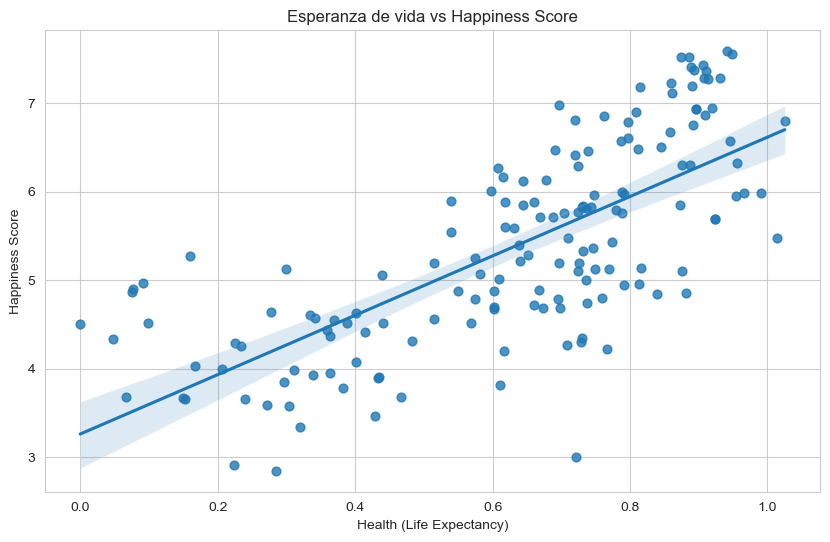

In [9]:
# Creamos una figura para el segundo análisis
plt.figure(figsize=(10, 6))

# Dibujamos la regresión entre esperanza de vida y felicidad
sns.regplot(
    data=df,
    x='Health (Life Expectancy)',
    y='Happiness Score',
    scatter_kws={'s': 40}
)

# Añadimos un título y etiquetas a los ejes
plt.title('Esperanza de vida vs Happiness Score')
plt.xlabel('Health (Life Expectancy)')
plt.ylabel('Happiness Score')
plt.show()


## 🛠️ Paso 3: Regresión múltiple según categoría (usando lmplot)

**Objetivo:** Identificar si la tendencia de regresión se mantiene consistente o varía al separar los datos por categorías.

**Instrucciones:**
1. Utiliza específicamente la función `lmplot` de Seaborn (que es ideal para introducir variables categóricas en regresiones).
2. Pon en X la columna relacionada con la libertad (`Freedom` o `Freedom to make life choices`) y en Y el `Score`.
3. Utiliza el parámetro `hue` (color) para separar las líneas de regresión por la región a la que pertenece el país (`Region`).
*Nota: Si estás usando datos donde no viene la Región, puedes usar hue para otra variable categórica o saltar el 'hue' y enfocarte solo en el lmplot general.*

Text(0.5, 1.02, 'Freedom vs Happiness Score por Region')

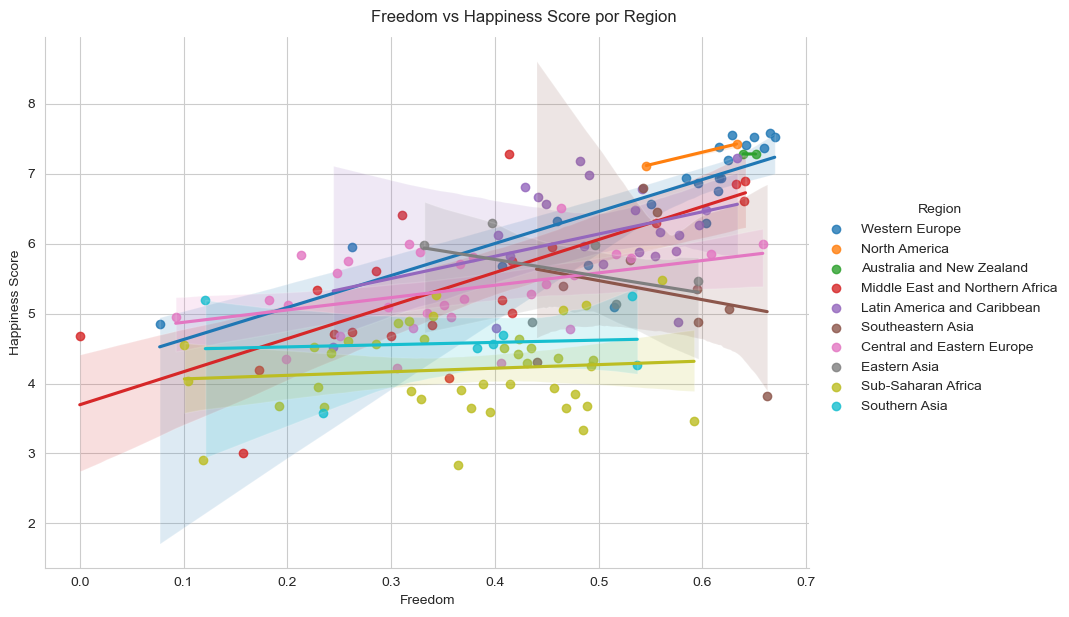

In [10]:
# Creamos una regresión separada por región
grafico = sns.lmplot(
    data=df,
    x='Freedom',
    y='Happiness Score',
    hue='Region',
    height=6,
    aspect=1.4
)

# Añadimos un título general al gráfico
grafico.fig.suptitle('Freedom vs Happiness Score por Region', y=1.02)


## 🛠️ Paso 4: Customización Estética

**Objetivo:** Mejorar la claridad visual del gráfico de regresión personalizando los estilos de la línea y de los puntos.

**Instrucciones:**
1. Haz un gráfico de regresión (`regplot`) comparando nuevamente el PIB per cápita (X) con la Felicidad (Y).
2. Pásale el diccionario de parámetros `scatter_kws={'alpha': 0.5}` para hacer los puntos semi-transparentes.
3. Pásale el diccionario de parámetros `line_kws={'color': 'red'}` para colorear la línea de regresión de color rojo para que contraste fuertemente.
4. Añade un título descriptivo y personaliza las etiquetas de los límites usando `plt.title()`, `plt.xlabel()` y `plt.ylabel()`.

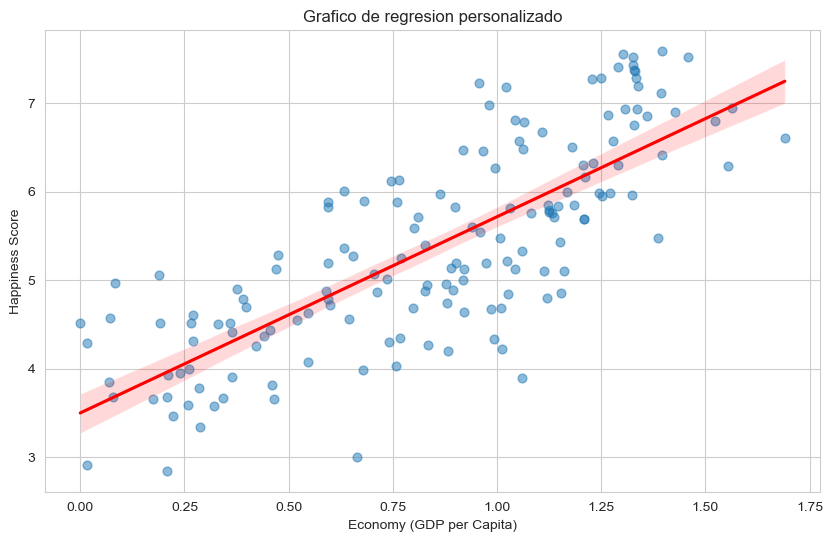

In [11]:
# Creamos una figura para personalizar la gráfica
plt.figure(figsize=(10, 6))

# Dibujamos la regresión con puntos semitransparentes y línea roja
sns.regplot(
    data=df,
    x='Economy (GDP per Capita)',
    y='Happiness Score',
    scatter_kws={'alpha': 0.5, 's': 40},
    line_kws={'color': 'red'}
)

# Añadimos un título y etiquetas a los ejes
plt.title('Grafico de regresion personalizado')
plt.xlabel('Economy (GDP per Capita)')
plt.ylabel('Happiness Score')
plt.show()


## 🌟 Reflexión Final del Alumno

**Tómate un rato.** 
Como has podido notar en esta lección:
* Una **gráfica de regresión** añade gran valor respecto a un scatter plot básico porque resume mediante un modelo lineal simple toda la agrupación de datos.
* Los puntos cercanos a la línea significan una fuerte correlación estadística, mientras que si están muy dispersos, la relación no es tan sólida (o quizás no sea puramente lineal).
* Observar valores atípicos (esos países que se alejan de la línea roja a gran distancia) te daría pistas de casos excepcionales en el mundo.

**Asegúrate que tu código de las celdas anteriores esté exhaustivamente comentado por ti en cada paso importante...**

## REFLEXION FINAL
- Es muy cómodo a golpe de vista ver las líneas de regresión. Con el scatter incluso mejor porque puedes "medir" a golpe de vista lo dispersos que están los datos con respecto a la línea, y eso dice mucho de cómo se comportan los datos.
- El gráfico de seaborn lmplot, aunque parece un poco inabordable al principio queda claro cuando se comprende, casi todas las líneas van ascendientes, excepto las de algunos países asiáticos, donde se ve que la felicidad es descendiente con respecto a la libertad.
- El modificar el parámetro "hue" nos ayuda también a diferenciar inmediatamente diferentes regiones